### Libraries

In [ ]:
#Cargas
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt



from sklearn.impute import SimpleImputer

# Definición de la función
def load_data():
    candidates = [
        Path('/content/datos_genero_filtrados.xlsx'),   
        Path('data/raw/datos_genero_filtrados.xlsx'),   
        Path('datos_genero_filtrados.xlsx'),            
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_excel(p)
            print("=== Dataset cargado ===")
            print(f"Archivo: {p} | Filas={df.shape[0]} | Columnas={df.shape[1]}")
            display(df.head(3))
            return df
    raise FileNotFoundError('No se encontró datos_genero_filtrados.xlsx en rutas conocidas.')


df = load_data() 


=== Dataset cargado ===
Archivo: /content/datos_genero_filtrados.xlsx | Filas=235 | Columnas=36


,profesionales,edad,motivo_de_consulta,medio_por_el_que_ingresa,genero,nacionalidad,barrio,municipio,localidad,estado_civil,...,simbolica,ambiental,politica,digital,cant_tipos_violencias_por_persona,denuncio,medidas_de_proteccion,fecha_fin_de_vigencia,personas_a_cargo,red_vincular
0,Fanny / Dana,28.0,VIOLENCIA,NaN,Mujer,Argentina,bordeu,Bahía Blanca,Bahía Blanca,Soltera,...,0.0,0.0,0.0,0.0,2.0,NO,NO,NaN,NO,PARIENTES CONVIVIENTES
1,Agus/ Analé,43.0,VIOLENCIA,NaN,Mujer,Argentina,pacifico,Bahía Blanca,Bahía Blanca,NaN,...,0.0,1.0,0.0,0.0,4.0,SI,Prohibición de acercamiento,NaN,Hija/Hijo,PARIENTES NO CONVIVIENTES
2,Fanny/ Majo,53.0,VIOLENCIA,NaN,Mujer,Argentina,pampa central,Bahía Blanca,Bahía Blanca,Soltera,...,0.0,0.0,0.0,0.0,2.0,NO,NO,NaN,NO,PARIENTES NO CONVIVIENTES



# Universidad Nacional de la Matanza

Specialization in Data Science

Benko Teo

Cura Diego

Riganti Valentina

Sanjuan Oriana


Model based on data from the Dirección General de Género de Bahía Blanca

---

Project: Implement an early warning system within the Dirección General de Género of the Municipality of Bahía Blanca to predict individuals with a higher probability of not filing formal complaints through the appropriate channels (Comisaría de la Mujer and UFI).

---

**Stage: Literature & Background Review (Similarities and Previous Experiences)**

After conducting research on project similarities and potential previous experiences, the existing background can be divided into several categories:

1. Early Detection Guides and Tools — Argentina (Ministry): There are national technical materials that promote the identification of early warning signs of gender-based violence (tools to detect indicators and design preventive interventions). They are not automated.

2. Monitoring and Device Projects (e.g., “Dispositivo MARIANA”) in Argentina: There are technological developments and devices designed as alert systems for femicide prevention and alerts for potential victims; they demonstrate an interest in technological solutions. They have not been fully implemented.

3. Application of Machine Learning for Gender-Based Violence in Academic Research: Recent literature includes systematic work and mapping on the use of predictive models to identify risk in intimate partner violence and patterns that help predict the probability of reporting or severe risk (in Argentina, models with high AUC have been reported in local literature). This shows that hybrid approaches (rules + ML) have been explored. Results vary and depend heavily on data quality:

A) Argentine validation of the Severe Violence Risk Prediction Scale (EPV-R) — AUC ≈ 0.69. (Torres Barbero and Ávalos Ávalos, 2025).

B) Longitudinal studies / risk assessment with structured instruments (SARA / RVD, by K. Arbach et al.) — AUC reported in related studies: 0.63 to 0.89 (varies by instrument and sample). (Arbach and Folino, 2020).

C) Local work with low performance (study on burn sites related to violence) — AUC = 0.48. (Cei et al, 2024).

4. International Guidelines on EWS with a Gender Perspective (UN / OAS / UN Women): There are methodological guides on how to design gender-sensitive early warning systems, emphasizing appropriate indicators, women's participation, and response design. Utilizing them helps avoid bias and protection errors.

5. Consolidated National Systems (e.g., VioGén / updates in Spain): There are national tracking and alert systems that centralize police and judicial information to assess risk and coordinate protection; they serve as a reference for scope, limitations, and risks (interoperability, privacy, technical errors).

Initial Feasibility Study
The background analysis demonstrates that there is technical documentation and pilot projects both in Argentina and internationally that support the technical feasibility and relevance of this project. Furthermore, numerous challenges can be listed, such as interoperability, errors, technical failures, and ethical considerations. For this reason, it is advisable to start with a local, supervised pilot with clear rules, decision logging, and evaluation.

The summary of the feasibility analysis is presented below:

Technical Feasibility
High. Promising results (AUC up to 0.89) have been reported using ML in the same context of risk assessment. Predicting the failure to report is a classic Classification problem.

Necessity / Relevance
Very High. The objective aligns directly with the Early Detection Guides and Tools and the interest in Monitoring and Device Projects in Argentina.

Main Risks
Moderate to High (but manageable). The challenge is not the algorithm, but the quality, volume, and biases of the dataset. The fact that one study reported an AUC of 0.48 underscores that success will critically depend on whether the data captured includes the correct indicators for non-reporting.

Key Condition
Begin with a Local and Supervised Pilot. As mentioned in the background analysis, this approach allows for the evaluation of data quality and model results with clear rules and decision logging before a large-scale implementation.


# **Stage: Data Pre-visualization and Discovery**

## The Dataset

The original dataset consists of 39 variables and 235 records ($N=235$).
However, in order to protect personal data (as we are working within the public Colab environment), it was decided to remove three variables that uniquely identified the individual who contacted the service to report their case. Including them poses a privacy risk and does not help the model generalize for future cases. These variables are:

Full name (nombre_y_apellido): The person contacting the service.

ID Number (documento): The unique identification of the person (DNI).

Address (domicilio): Where the person lives (includes exact street numbering).


Below is a dictionary for the 36 remaining variables with a brief description of the recorded data:


*Case Descriptors:

Assigned Professionals (profesionales): To whom the case is assigned.

Reason for Consultation (motivo_de_consulta).

Intake Channel (medio_por_el_que_ingresa): The method through which the case entered the system.

Location Identification:

Nationality (nacionalidad).

Neighborhood (barrio).

Municipality (municipio).

Town/City (localidad).


*General Descriptors of the Person:

Age (edad).

Gender (genero).

Socioeconomic and Status Indicators:

Marital Status (estado_civil).

Educational Level (nivel_educativo).

Employment Status (situacion_laboral).

Receives State Benefits (percibe_prestacion_estatal).

Housing Situation (vivienda).

Health Insurance (obra_social).


*Clinical, Risk, and Family Indicators:
Diagnosis (diagnóstico).

Treatment (tratamiento).

Disability Certificate (posee_cud): Indicates if the person holds a CUD.

Number of Dependents (cant_personas_a_cargo).

Children/Adolescents (hijos_pea): Presence of children or teenagers in common with the agressor.

Cohabitation with agressor (convivencia_pea).

Violence Modality (modalidad_de_violencia).

Types of Violence:Physical (fisica).

Psychological (psicologica).

Sexual (sexual).Economic (economica).

Symbolic (simbolica).Environmental (ambiental).

Political (politica).Digital (digital).

Number of Violence Types per Person (cant_tipos_violencias_por_persona): Total count of reported types of violence.

*Case Resolution:Filed a Complaint (denuncio): [Target Variable] Whether the formal report was made.

Post-Reporting Details (When a complaint WAS filed)

Protection Measures (medidas_de_proteccion).

Expiration Date (fecha_fin_de_vigencia): End of validity for protection measures.

Dependents (personas_a_cargo).

Support Network (red_vincular).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   profesionales                      231 non-null    object 
 1   edad                               225 non-null    float64
 2   motivo_de_consulta                 219 non-null    object 
 3   medio_por_el_que_ingresa           188 non-null    object 
 4   genero                             231 non-null    object 
 5   nacionalidad                       229 non-null    object 
 6   barrio                             235 non-null    object 
 7   municipio                          233 non-null    object 
 8   localidad                          234 non-null    object 
 9   estado_civil                       214 non-null    object 
 10  nivel_educativo                    208 non-null    object 
 11  situacion_laboral                  190 non-null    object 

## Variable Analysis

The dataset variables are analyzed.

In [ ]:
# Unique values are reviewed to proceed with the previsualization

print("--- REVISIÓN DE VALORES ÚNICOS POR COLUMNA ---")

# A threshold is defined --> If there are more than 50 unique values, they are not all printed.
DISPLAY_THRESHOLD = 50

for col in df.columns:
    # 1. Counting the number of unique values
    num_unicos = df[col].nunique()

    # 2. Print the column header
    print(f"\n--- Columna: '{col}' (Tipo: {df[col].dtype}) ---")
    print(f"Total de valores únicos: {num_unicos}")

    # 3. Decide whether to display the values or not
    if num_unicos > UMBRAL_PARA_MOSTRAR:
        # If there are too many, only the first 5 are shown as examples
        print("Valores (ejemplos):")
        print(df[col].unique()[:5])
    else:
        # If there are few, all of them are displayed
        print("Valores:")
        print(df[col].unique())

print("\n--- Fin de la revisión ---")

### Analysis of Consultation Variables (Assigned Professional, Reason for Consultation, and Intake Channel):

In [ ]:
# Function to analyze and display the table for a categorical variable
def generate_categorical_table(df, column_name):
    # 1. Calculate the Value Count, including Nulls (dropna=False)
    counts = df[column_name].value_counts(dropna=False)
    total_rows = len(df)

    # 2. Replace the NaN index with a label
    counts.index = counts.index.fillna('Null (No data)')

    # 3. Table Layout
    percentages = (counts / total_rows) * 100
    analysis_df = pd.DataFrame({
        'Conteo': counts,
        'Porcentaje (%)': percentages.round(2)
    }).sort_values(by='Conteo', ascending=False)

    print(f"\n--- Tabla de Conteo de la Variable '{column_name}' (Pre-limpieza) ---")

    # Limit the output of the 'profesionales' table to the top 10 most frequent categories for readability
    if column_name == 'profesionales':
        print(analysis_df.head(10).to_markdown())
    else:
        print(analysis_df.to_markdown())

# Definition of columns to analyze and table generation:
col_consulta = ['profesionales', 'motivo_de_consulta','medio_por_el_que_ingresa']

for col in col_consulta:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'profesionales' (Pre-limpieza) ---
| profesionales       |   Conteo |   Porcentaje (%) |
|:--------------------|---------:|-----------------:|
| Ana/Gladis          |       11 |             4.68 |
| Analé/Ana           |        5 |             2.13 |
| Fernanda            |        4 |             1.7  |
| Nulo (Sin dato)     |        4 |             1.7  |
| Agus / Rami         |        4 |             1.7  |
| María José/Fernanda |        4 |             1.7  |
| Fernanda/Leandro    |        4 |             1.7  |
| Flor/Ana            |        3 |             1.28 |
| Rami/Ceci           |        3 |             1.28 |
| Alejandra/Fernanda  |        3 |             1.28 |

--- Tabla de Conteo de la Variable 'motivo_de_consulta' (Pre-limpieza) ---
| motivo_de_consulta   |   Conteo |   Porcentaje (%) |
|:---------------------|---------:|-----------------:|
| VIOLENCIA            |      202 |            85.96 |
| Nulo (Sin dato)      |       16 |     

    'profesionales':

The combination of possible professionals handling the cases is very large. This variable shows extreme dispersion of values with very low frequency per category, given how the data was originally recorded.

An arduous cleaning task is required to address spelling inconsistencies and attempt a proper transformation of the names of the individuals involved. Possible examples found include: "Ana/Rami" vs. "Ana/Ramiro" vs. "Rami.Ana."

The crucial question would be: Could the professional influence the reason for filing a complaint? Does it have to do with the treatment provided?

Action: According to discussions with the Dirección General de Género, the first-stage staff is administrative: they only register the case and provide an appointment with the indicated professionals. In other words, the predisposition to file a complaint or not does not depend on the attending professionals; therefore, the cleaning process will likely require removing this variable.


    'motivo_de_consulta':

A clear bias toward a single category is observed (VIOLENCIA - 86% of cases).

Action: This suggests that the variable will have little predictive power, as nearly all cases belong to the same class. Furthermore, after consulting with the Dirección, they confirmed that all cases are consultations regarding situations of violence. Therefore, it may be a candidate for removal during the cleaning process.


    'medio_por_el_que_ingresa':


This refers to the means by which the individual establishes contact with the Dirección.

Significant Data Absence: 20% of the data is missing or unknown, which is significant. This should be unified with 'No Data' (sin datos). Potentially, an 'Unknown' (desconocido) intake channel could be associated with non-reporting, so it is not advisable to remove it.

Action: Group 'Null (no data)' (Nulo(sin dato)) and 'No Data' (sin datos) into a single 'Unknown' (Desconocido) category.

High Formality Bias: Almost 60% of entries come through highly formal channels: Judicial Notification (Notificación judicial) at 35.32% or Spontaneous/Walk-in (Espontánea) at 21.28%.

Low-Frequency Categories: Several categories have very low frequencies (less than 2.5%), such as Health Units (Unidad Sanitaria), Hospitals (Hospital), or Educational Institutions (Institución educativa). These could be grouped into a single class along with 'Other' (otra) to create a group called 'Other Channels' (Otros Canales).

Action: Make specific decisions based on these findings to reduce cardinality to 5–6 stable categories.


### Analysis of variables describing the location of the person contacting the service:

In [ ]:
# Definition of columns to analyze and table generation:
col_ubi = ['nacionalidad','barrio','municipio', 'localidad']

for col in col_ubi:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'nacionalidad' (Pre-limpieza) ---
| nacionalidad    |   Conteo |   Porcentaje (%) |
|:----------------|---------:|-----------------:|
| Argentina       |      219 |            93.19 |
| Nulo (Sin dato) |        6 |             2.55 |
| S/D             |        5 |             2.13 |
| sin datos       |        2 |             0.85 |
| Chilena         |        2 |             0.85 |
| No              |        1 |             0.43 |

--- Tabla de Conteo de la Variable 'barrio' (Pre-limpieza) ---
| barrio                |   Conteo |   Porcentaje (%) |
|:----------------------|---------:|-----------------:|
| sin datos             |       20 |             8.51 |
| noroeste              |       20 |             8.51 |
| ingeniero white       |       11 |             4.68 |
| centro                |        7 |             2.98 |
| vista alegre          |        6 |             2.55 |
| villa rosas           |        5 |             2.13 |
| spurr           

    'nacionalidad':

A clear imbalance is observed toward the ARGENTINA class — 93% of cases.

The categories S/D, sin datos (no data), and Nulo (null) represent 5.53% of the total.

Action: During the cleaning phase, it is recommended to unify all non-Argentine records into a single category. Secondly, it is recommended to transform the variable into a binary predictor that captures the deviation and manages the class imbalance (ARGENTINA = 1; Other = 0). This maintains the model's sensitivity and prevents overfitting.


    'barrio':

On one hand, a high percentage (29.36%) of the data is null. On the other hand, there are 99 unique categories, which makes standardization difficult.

Neighborhood information can be valuable within the context of the analysis (geographical risk); therefore, a way must be found to reduce the number of categories to a reasonable amount (between 5 and 10).

Action: A possible option for the cleaning phase is to group neighborhoods by a specific characteristic (e.g., distance to the city center, socioeconomic status, or zoning, provided an external dictionary can be obtained).


    'municipio' y 'localidad'

These provide very similar information.

Action: During the cleaning phase, typographical errors must be corrected to reveal the true distribution (Example: bahia blanca vs. Bahía Blanca vs. bahia Blanca). This makes the variables, once cleaned, have low predictive power, as the vast majority of cases would fall into a single dominant category (97% "Bahía Blanca" for 'locality' and 98% for 'municipality').

### Analysis of variables describing the person's characteristics:

In [ ]:
df['edad'].describe()

,edad
count,225.000000
mean,38.248889
std,12.597134
min,17.000000
25%,29.000000
50%,36.000000
75%,45.000000
max,85.000000


In [ ]:
# Definition of columns to analyze and table generation:
col_gen = ['genero']

for col in col_gen:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'genero' (Pre-limpieza) ---
| genero          |   Conteo |   Porcentaje (%) |
|:----------------|---------:|-----------------:|
| Mujer           |      228 |            97.02 |
| Nulo (Sin dato) |        4 |             1.7  |
| sin datos       |        2 |             0.85 |
| Otro            |        1 |             0.43 |


    'edad':

They fall within an age range of 17 to 85 years, with a mean age of 38 and a median of 36. The majority of the people who contact the service (75%) are up to 45 years old.

Action: An attempt can be made to classify the variable into age groups (bins) to reduce cardinality.

Transform the variable type to integer.

    'genero':

A clear imbalance is observed toward a single category (FEMALE - 97% of cases). This limits its predictive power. However, by removing the variable during the cleaning phase, the model might fail to distinguish noteworthy cases from other genders, potentially hiding critical patterns—for instance, if men or trans individuals have a different probability of not reporting compared to the majority.

Action: The variable could be transformed into a binary predictor that captures the deviation and manages the class imbalance (FEMALE = 0; Other = 1). This maintains the model's sensitivity and prevents overfitting.

### Analysis of Socioeconomic and Status Variables:

In [ ]:
# Definition of columns to analyze and table generation:
col_general = ['estado_civil','nivel_educativo','situacion_laboral','percibe_prestacion_estatal',
'vivienda','obra_social']

for col in col_general:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'estado_civil' (Pre-limpieza) ---
| estado_civil       |   Conteo |   Porcentaje (%) |
|:-------------------|---------:|-----------------:|
| Soltera            |       97 |            41.28 |
| Casada             |       50 |            21.28 |
| Separada           |       33 |            14.04 |
| Nulo (Sin dato)    |       21 |             8.94 |
| Unión Convivencial |       13 |             5.53 |
| Divorciada         |       10 |             4.26 |
| Viuda              |        7 |             2.98 |
| sin datos          |        4 |             1.7  |

--- Tabla de Conteo de la Variable 'nivel_educativo' (Pre-limpieza) ---
| nivel_educativo                    |   Conteo |   Porcentaje (%) |
|:-----------------------------------|---------:|-----------------:|
| Secundario incompleto              |       67 |            28.51 |
| Secundario completo                |       40 |            17.02 |
| Nulo (Sin dato)                    |       27 |  


    'estado_civil':

The majority of the values are Single (Soltera - 41.28%) and Married (Casada - 21.28%).

Actions:
Group Nulls (8.94%) and No Data (sin datos - 1.70%) into a single category such as 'Unknown' (Desconocido).

There are functionally similar categories that can be grouped together (Example: Separated (Separada) vs. Divorced (Divorciada)).


    'nivel_educativo':

There are many typographical errors to correct (Example: sin datos vs. Sin datos vs. Nulo (sin datos) / incompletp vs. incompleto / Univrtsitario vs. Universitario) and minority categories that can be grouped together (Example: incompleto, universitario).

    'situacion_laboral':

There are many typographical errors to correct (Example: Trabaja formal vs. Trabajo formal / No trabaja vs. No Trabaja).

There are functionally similar categories that can be grouped together (Example: Does not work (No trabaja) with Unemployed (Desocupado) / all registered/formal jobs vs. all unregistered/informal jobs).

Action: After the cleaning process, the majority class can be identified, and the resulting categories can be standardized.

    'percibe_prestacion_estatal':

AUH ($32.77\%$) is the most common social benefit.

Actions:

Group Nulls/No Data: Consolidate "nulls" and "no data" (sin datos) into a single category.

Impute Majority Class: The combination of (NaN, S/D) is the majority category (40%). The Dirección has indicated that this absence of data means the individual does not receive a benefit. Therefore, it should be imputed as "No". The same applies to "Child Support" (cuota alimentaria), as it is a legal right of the children and not a social benefit for the consultant.

Reduce Cardinality: Group low-frequency benefits (e.g., 'ALIMENTAR') into a single category labeled 'Other Benefits' (Otras Prestaciones).

    'vivienda':

'Propia' ($38.72\%$) y 'Alquilada' ($19.57\%$) are the dominant ones.

Actions:

Group Nulls/No Data: Consolidate "nulls" and "no data" into a single category (No data / S/D).

Reduce Cardinality: Group very low-frequency or similar classes into an 'Others' category.


    'obra_social':

The majority DO NOT have health insurance (50.64%). Null values indicate that the individual does not have health insurance.

Actions:

Impute Null Values: Set as NO.

Fix Typographical Errors: Correct cases such as 'No' vs. 'no'.

Apply One-Hot Encoding: Create two binary features: YES / NO.

### Analysis of descriptors regarding Clinical, Risk, and Family characteristics:

In [ ]:
# Definition of columns to analyze and table generation:
col_familiar = ['diagnostico','tratamiento','posee_cud','cant_personas_a_cargo',
'hijos_pea','convivencia_pea']

for col in col_familiar:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'diagnostico' (Pre-limpieza) ---
| diagnostico        |   Conteo |   Porcentaje (%) |
|:-------------------|---------:|-----------------:|
| Nulo (Sin dato)    |      126 |            53.62 |
| si                 |       39 |            16.6  |
| no                 |       36 |            15.32 |
| No                 |       30 |            12.77 |
| consum antidep.    |        2 |             0.85 |
| Enfermedad crónica |        1 |             0.43 |
| Opción 1           |        1 |             0.43 |

--- Tabla de Conteo de la Variable 'tratamiento' (Pre-limpieza) ---
| tratamiento     |   Conteo |   Porcentaje (%) |
|:----------------|---------:|-----------------:|
| Nulo (Sin dato) |      137 |            58.3  |
| si              |       33 |            14.04 |
| No              |       31 |            13.19 |
| no              |       30 |            12.77 |
| Opción 1        |        2 |             0.85 |
| sin datos       |        2 |     

The variables analyzed in this section share several common issues to be corrected during the cleaning phase, such as typographical errors (no vs. No) and the grouping of similar categories, like Null (No data) and no data.

    'diagnostico':

The majority (53.62%) are null. If there is no data, it is NO.

If it contains other values such as "enfermedad crónica" (chronic illness) or "consume antidep." (takes antidepressants), it is considered YES.

Here is the translation into English:

Actions:

Impute Nulls: Set null values to NO.

Correct Records: Standardize entries (e.g., no, No).

The goal is to identify whether a diagnosis exists or not; therefore, the recommended action is to convert the variable into a binary format (1 for "consum antidep." / "Enfermedad crónica" / "si" — 0 for all other cases, i.e., "NO" and nulls).


    'tratamiento':

The majority (58.30%) are null. If there is no data, it is NO.

Actions:

Impute Nulls: Set null values to NO.

Correct Records: Standardize entries (no, No, sin datos).

The goal is to identify whether treatment exists or not (similar to 'diagnosis'); therefore, the recommended action is to convert the variable into a binary format (1 if "SI" — 0 in all other cases, i.e., "NO" and nulls).


    'posee_cud':

The majority are null (51.49%). If there is no data, it is NO.

Action: Evaluate the application of One-Hot Encoding to create two binary features: YES / NO.


    'cant_personas_a_cargo':

36.60% are null records. If there is no data, it is NO (meaning 0 dependents).

The categorical value 'NO' is mixed with numerical values (zero dependents), which causes the data type to be incorrectly interpreted as an object (it should be an integer)

Action: Correct this mapping during the cleaning phase and convert everything to numerical values.


    'hijos_pea':

The 'Yes' (Si) class (44.26%) is the most frequent, while 30.64% of the total are null values, meaning NO.

Actions:

No typographical errors are observed.

Set null values to NO.

Assess the application of One-Hot Encoding to create two binary features: YES / NO.

    'convivencia_pea':

La clase 'NO' ($47.66\%$) es la más frecuente.El $44.68\%$ del total son nulos, es decir, NO.

Acciones recomendadas:

Corregir registros (sin datos).
Imputar nulos a NO.


Evaluación de aplicación Codificación One-Hot para crear dos features binarios: SI / NO

### Analysis of Violence Descriptors

In [ ]:
# Definition of columns to analyze and table generation:
col_violencia = ['modalidad_de_violencia','cant_tipos_violencias_por_persona']

for col in col_violencia:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'modalidad_de_violencia' (Pre-limpieza) ---
| modalidad_de_violencia   |   Conteo |   Porcentaje (%) |
|:-------------------------|---------:|-----------------:|
| Doméstica                |      188 |            80    |
| Nulo (Sin dato)          |       46 |            19.57 |
| sin datos                |        1 |             0.43 |

--- Tabla de Conteo de la Variable 'cant_tipos_violencias_por_persona' (Pre-limpieza) ---
| cant_tipos_violencias_por_persona   |   Conteo |   Porcentaje (%) |
|:------------------------------------|---------:|-----------------:|
| Nulo (Sin dato)                     |      205 |            87.23 |
| 2.0                                 |       16 |             6.81 |
| 4.0                                 |        5 |             2.13 |
| 1.0                                 |        5 |             2.13 |
| 3.0                                 |        2 |             0.85 |
| 5.0                                 |     

In [ ]:
df.describe()

,edad,fisica,psicologica,sexual,economica,simbolica,ambiental,politica,digital,cant_tipos_violencias_por_persona
count,225.000000,226.000000,227.000000,227.000000,227.000000,227.000000,224.000000,227.000000,227.000000,30.000000
mean,38.248889,0.513274,0.669604,0.167401,0.264317,0.149780,0.267857,0.004405,0.039648,2.433333
std,12.597134,0.500933,0.471395,0.374158,0.441943,0.357644,0.443835,0.066372,0.195561,1.165106
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,36.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,45.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,3.000000
max,85.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000


In [ ]:
# Definition of columns to analyze and table generation:
columnas_tipos = ['fisica','psicologica','sexual','economica','simbolica','ambiental',
                  'politica','digital']

for col in columnas_tipos:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'fisica' (Pre-limpieza) ---
| fisica          |   Conteo |   Porcentaje (%) |
|:----------------|---------:|-----------------:|
| 1.0             |      116 |            49.36 |
| 0.0             |      110 |            46.81 |
| Nulo (Sin dato) |        9 |             3.83 |

--- Tabla de Conteo de la Variable 'psicologica' (Pre-limpieza) ---
| psicologica     |   Conteo |   Porcentaje (%) |
|:----------------|---------:|-----------------:|
| 1.0             |      152 |            64.68 |
| 0.0             |       75 |            31.91 |
| Nulo (Sin dato) |        8 |             3.4  |

--- Tabla de Conteo de la Variable 'sexual' (Pre-limpieza) ---
| sexual          |   Conteo |   Porcentaje (%) |
|:----------------|---------:|-----------------:|
| 0.0             |      189 |            80.43 |
| 1.0             |       38 |            16.17 |
| Nulo (Sin dato) |        8 |             3.4  |

--- Tabla de Conteo de la Variable 'economica' (Pre-

    'modalidad_de_violencia':

The 'Domestic' (Doméstica) category dominates with 80% of the records, which may bias the model. It is almost a constant variable.

The more detailed information is contained in the binary variables for the type of violence (physical, psychological, etc.).

*Types of violence*

These variables share a similarly low percentage of null values (not exceeding 5%) and are presented in boolean format (True/False). Therefore, there are two possible recommended actions for cleaning:

Convert True = 1 ; False = 0 (to transform them into binary variables).

Impute absences / nulls as '0'.

The order of occurrence (True) would be as follows:

    'Physical' ('fisica'): Balanced between T/F (nearly 50%).

    'Psychological' ('psicologica'): The most common form of violence (occurs nearly 65% of the time).

    'Economic' ('economica'): Moderate presence (does not occur 70% of the time).

    'Environmental' ('ambiental'): Moderate presence (does not occur nearly 70% of the time).

    'Sexual' ('sexual'): Low presence (does not occur 80% of the time).

    'Symbolic' ('simbolica'): Low presence (does not occur 82% of the time).

    'Digital' ('digital'): Very low presence (occurs nearly 4% of the time).

    'Political' ('politica'): Almost constant non-occurrence (happens only 0.43% of the time).


    'cant_tipos_violencias_por_persona':

The hypothesis is that it represents the total count of reported types of violence. However, it contains a high number of nulls (205 records, which accounts for 87% of the data); therefore, we will perform an additional verification on the 30 records where the count was actually documented.

In [ ]:
# 1. Define the 8 binary violence columns and the count column
violence_cols = [
    'fisica', 'psicologica', 'sexual', 'economica', 'simbolica',
    'ambiental', 'politica', 'digital'
]
count_col = 'cant_tipos_violencias_por_persona'

# 2. Create a temporary DataFrame for cleaning and comparison
df_temp = df.copy()

# 3. Clean and convert binary violence columns (True/False to 1/0, NaN to 0)
for col in violence_cols:
    # Handle the string/boolean values. Map True to 1, False/string 'False' to 0.
    # The value counts showed True/False as strings/bools. Using map is safer.
    df_temp[col] = df_temp[col].map({True: 1, False: 0, 'True': 1, 'False': 0})
    # Fill remaining NaNs (which represent unrecorded violence) with 0
    df_temp[col] = df_temp[col].fillna(0).astype(int)

# 4. Calculate the sum of the cleaned binary columns
df_temp['sum_violencias'] = df_temp[violence_cols].sum(axis=1)

# 5. Clean the recorded count column by converting to numeric (will leave NaNs)
df_temp[count_col] = pd.to_numeric(df_temp[count_col], errors='coerce')

# 6. Compare the two columns only where the recorded count is NOT null
# We only care about the cases where 'cant_tipos_violencias_por_persona' was actually recorded.
comparison_subset = df_temp[df_temp[count_col].notna()]

# 7. Count matches and mismatches
matches = (comparison_subset['sum_violencias'] == comparison_subset[count_col]).sum()
total_recorded = comparison_subset.shape[0]
mismatches = total_recorded - matches

# Calculate the difference for inspection (if any)
comparison_subset['difference'] = comparison_subset['sum_violencias'] - comparison_subset[count_col]
sample_mismatch = comparison_subset[comparison_subset['difference'] != 0].head(5)

print(f"--- Verificación de la Redundancia de '{count_col}' ---")
print(f"Registros donde se registró el conteo: {total_recorded}")
print(f"Registros donde el conteo coincide con la suma: {matches}")
print(f"Registros donde el conteo NO coincide con la suma: {mismatches}")

if mismatches > 0:
    print("\nEjemplo de Mismatches (Diferencia > 0 significa que la suma es mayor que el conteo registrado):")
    # Display the violence flags, the recorded count, the calculated sum, and the difference
    display_cols = violence_cols + [count_col, 'sum_violencias', 'difference']
    print(sample_mismatch[display_cols].to_markdown(index=False))
else:
    print("\n¡El conteo es completamente redundante con la suma de las variables binarias!")

--- Verificación de la Redundancia de 'cant_tipos_violencias_por_persona' ---
Registros donde se registró el conteo: 30
Registros donde el conteo coincide con la suma: 28
Registros donde el conteo NO coincide con la suma: 2

Ejemplo de Mismatches (Diferencia > 0 significa que la suma es mayor que el conteo registrado):
|   fisica |   psicologica |   sexual |   economica |   simbolica |   ambiental |   politica |   digital |   cant_tipos_violencias_por_persona |   sum_violencias |   difference |
|---------:|--------------:|---------:|------------:|------------:|------------:|-----------:|----------:|------------------------------------:|-----------------:|-------------:|
|        0 |             0 |        0 |           0 |           0 |           0 |          0 |         0 |                                   2 |                0 |           -2 |
|        1 |             1 |        0 |           1 |           0 |           1 |          0 |         0 |                                   2

/tmp/ipython-input-3886475569.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison_subset['difference'] = comparison_subset['sum_violencias'] - comparison_subset[count_col]


When comparing the sum of the 8 binary violence columns with the value recorded in cant_tipos_violencias_por_persona—focusing only on the $N=30$ records where the count was actually registered—the following is observed:

* 93% of the records where the count was registered DO MATCH the sum of the binary variables. This suggests that the variable is essentially redundant and was calculated from the binary flags.

* The 2 inconsistencies found are likely data entry errors; in the first case, all binary variables were set to '0' but the sum was recorded as 2, while in the second case, the binary sum was 4 but 2 was recorded.

Action: Drop the original variable and use the sum of the 8 cleaned binary violence variables to obtain the count metric. This resolves the issue of having a variable with nearly 87% nulls and provides a more robust feature, given that the source variables have less than 5% null values.

Note: This count should not be included in the set of predictors for the model if the individual types of violence are already included, as it was created from those variables and would cause multicollinearity.

### Analysis of target variable: complaint YES/NO

--- Conteo de la Variable 'denuncio' ---
| denuncio   |   Conteo |   Porcentaje (%) |
|:-----------|---------:|-----------------:|
| SI         |      139 |            59.15 |
| Sin dato   |       62 |            26.38 |
| NO         |       34 |            14.47 |


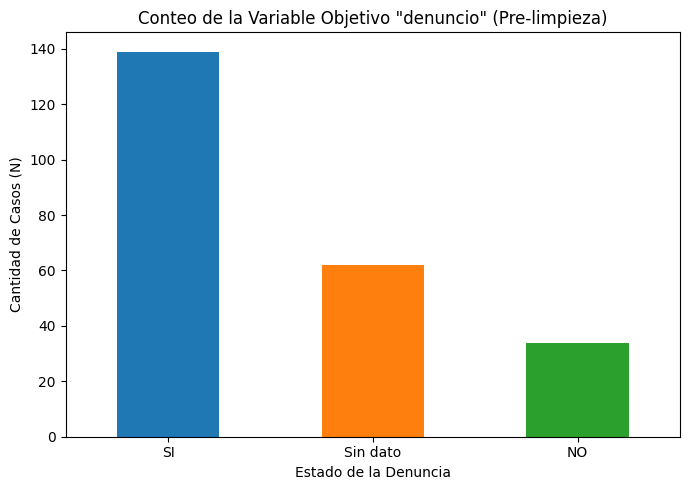

In [ ]:
# 1. Calculate Value Counts, including Nulls (dropna=False)
denuncio_counts = df['denuncio'].value_counts(dropna=False)
total_rows = len(df)

# Replace the NaN index with a label (SIN DATO=NO DATA) for the chart and the table
denuncio_counts.index = denuncio_counts.index.fillna('Sin dato')

# 2. Generate the bar chart
plt.figure(figsize=(7, 5))
denuncio_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Target Variable Count: "denuncio" (Pre-cleaning)')
plt.xlabel('Status of the Complaint ("Denuncia")')
plt.ylabel('Number of cases (N)')
plt.xticks(rotation=0) 
plt.tight_layout()

# 3. Display the analysis table
denuncio_percentages = (denuncio_counts / total_rows) * 100
denuncio_analysis_df = pd.DataFrame({
    'Conteo': denuncio_counts,
    'Porcentaje (%)': denuncio_percentages.round(2)
}).sort_values(by='Conteo', ascending=False)

print("--- Count of the Variable 'denuncio' ---")
print(denuncio_analysis_df.to_markdown())

    'denuncio':
As the variable is presented, we are facing a case of class imbalance. 14% of the cases indicate that there was NO complaint (the minority group that conflicts with what we aim to predict), and 26% correspond to nulls (missing data).
External information was crucial to provide context for these null values; understanding that when there is no data, it is because no formal complaint was filed in the justice system. This is known because the dataset records both confirmed and unconfirmed complaints, due to direct links and access to judicial system resolutions.

 Actions:

Set missing data (sin dato) to NO.

Convert the "denuncio" (complaint) column—now without nulls—into a binary numerical format.

#### Updated Analysis of the Target Variable (denuncia SI/NO)

Note: To understand what is described below, it is crucial to read the full assumption analysis performed in the subsequent section.

An assumption analysis was conducted to challenge the initial hypothesis ("If Complaint is Null, there was no complaint"). Based on a review of the variables 'protection_measures' (medidas_de_protección) and 'expiration_date' (fecha_fin_de_vigencia), it was postulated that "Data exists in these variables only when a formal complaint has been filed." This allowed for the identification of cases where 'complaint' was null but contained valid entries in the other two variables.

In line with the above, the key finding was that the rule provided by the external source must be questioned, as at least one record was found that does not comply with the premise that "every value entered as null is a 'NO complaint'." In short, the rule would be redefined as: "NULL complaints are corrected to 'YES' only if there is evidence that the judicial process occurred (simultaneous presence of protection measures and valid dates)."

**This requires that during the cleaning phase, an imputation rule is created for null values, with the understanding that if valid data exists in 'protection_measures' (medidas_de_protección) and 'expiration_date' (fecha_fin_de_vigencia) simultaneously for a record categorized as NULL in 'filed_complaint' (denuncio), it must be changed to 'YES'**

Given that protection measures have a maximum validity of six months and the analyzed dataset corresponds to the year 2025, it is not reasonable to consider outdated records as valid. For this reason, only records whose expiration_date (fecha_fin_de_vigencia) falls within the second half of 2024 onwards should be considered valid.

Thus, it is assumed that a date prior to July 2024 implies an obsolete or erroneous record, or one not linked to the current complaint. Conversely, a date equal to or later than that period constitutes evidence of a recent judicial measure and, therefore, of an effectively formalized complaint.

This decision is based on the limited validity of protection measures and the need to ensure temporal consistency between the different components of the judicial process.

### Assumption Analysis: Variables processed when a complaint WAS filed

In the data preview analysis, four variables remain to be observed. An initial assumption suggests that these are issues that only arise once a complaint has been formally filed.

This is the assumption we aim to refute or validate by observing the raw data of the dataset and the distribution of the variables under analysis.


In [ ]:
# Definition of columns to be analyzed and table generation:
col_proteccion = ['medidas_de_proteccion','fecha_fin_de_vigencia','personas_a_cargo','red_vincular']

for col in col_proteccion:
    generate_categorical_table(df, col)


--- Tabla de Conteo de la Variable 'medidas_de_proteccion' (Pre-limpieza) ---
| medidas_de_proteccion                            |   Conteo |   Porcentaje (%) |
|:-------------------------------------------------|---------:|-----------------:|
| Nulo (Sin dato)                                  |       93 |            39.57 |
| Prohibición de acercamiento                      |       89 |            37.87 |
| NO                                               |       40 |            17.02 |
| Botón antipánico/ Prohibición Acercamiento       |        6 |             2.55 |
| Botón Antipánico                                 |        2 |             0.85 |
| Prohibición de acercamiento/ Cese de hostigación |        2 |             0.85 |
| Exclusión del hogar                              |        2 |             0.85 |
| Cese hostigamiento                               |        1 |             0.43 |

--- Tabla de Conteo de la Variable 'fecha_fin_de_vigencia' (Pre-limpieza) ---
| fecha_fin_

Before analyzing each variable individually, the initial assumption regarding the data must be questioned:

> "There are records in these variables only when a formalized complaint EXISTS"

For the following analysis, explicit negative confirmations ('NO') and missing values ('Null(No data)' or 'no data') will be excluded, as the assumption would not be refuted by cases where there is a 'NO COMPLAINT' or 'NULL COMPLAINT' that also corresponds to a 'NO' in the variable being analyzed.

The objective is to evaluate only those cases where there are positive affirmations in the 4 variables, yet the complaint was marked as NO or NULL. Therefore, only records with the existence of positive data (a name, a protection measure, or a validity date) are considered.

In [ ]:
# Define the columns for the check
denuncia_col = 'denuncio'
risk_cols = ['medidas_de_proteccion', 'fecha_fin_de_vigencia','personas_a_cargo', 'red_vincular'
             ]

# --- 1. Define the subsets ---
# Subset 1: Cases where 'denuncio' is explicitly 'NO'
df_no = df[df[denuncia_col] == 'NO'].copy()
count_no = len(df_no)

# Subset 2: Cases where 'denuncio' is explicitly NaN (Nulo)
df_nulo = df[df[denuncia_col].isna()].copy()
count_nulo = len(df_nulo)

# --- 2. Define the strict counting function for a subset ---
# This function counts only 'positive confirmation' data, excluding 'NO', 'sin datos', and NaNs.
def count_strict_positive(subset_df, column_name):
    # Set of negative/null values to exclude (case-insensitive where applicable)
    negative_confirmations = {'NO', 'NO ', 'no', 'No', 'sin datos', 'S/D'}

    # Logic for counting non-negative, non-null entries
    if column_name == 'fecha_fin_de_vigencia':
        # For dates, any non-null value is a positive confirmation of a date/number.
        return subset_df[column_name].notna().sum()

    else:
        # Count where the value is NOT in the negative set and is NOT NaN.
        # We need to handle potential typos and case variations for 'NO'.
        def is_positive_data(val):
            if pd.isna(val):
                return False
            # Check against lowercase version for robustness
            val_lower = str(val).lower()
            if val_lower in [x.lower() for x in negative_confirmations]:
                return False
            return True

        return subset_df[column_name].apply(is_positive_data).sum()

# --- 3. Calculate Strict Positive Counts ---
data = {}
for col in risk_cols:
    count_no_strict = count_strict_positive(df_no, col)
    count_nulo_strict = count_strict_positive(df_nulo, col)

    data[col] = {
        'Conteo Positivo (Denuncia = NO)': count_no_strict,
        '% del Subconjunto NO': (count_no_strict / count_no) * 100,
        'Conteo Positivo (Denuncia = NULO)': count_nulo_strict,
        '% del Subconjunto NULO': (count_nulo_strict / count_nulo) * 100
    }

# Convert the dictionary to a DataFrame for presentation
results = pd.DataFrame.from_dict(data, orient='index')
results.index.name = 'Variable'

print(f"--- Hallazgo Detallado Estricto (Sólo Confimaciones Positivas de Dato) ---")
print(f"Total de casos con 'NO' Denuncia: {count_no}")
print(f"Total de casos con 'Nulo' Denuncia: {count_nulo}")
print("\nConteo de Registros Positivos (Excluyendo 'NO', 'Nulo', 'sin datos' o similares):")
print(results.round(2).to_markdown())

--- Hallazgo Detallado Estricto (Sólo Confimaciones Positivas de Dato) ---
Total de casos con 'NO' Denuncia: 34
Total de casos con 'Nulo' Denuncia: 62

Conteo de Registros Positivos (Excluyendo 'NO', 'Nulo', 'sin datos' o similares):
| Variable              |   Conteo Positivo (Denuncia = NO) |   % del Subconjunto NO |   Conteo Positivo (Denuncia = NULO) |   % del Subconjunto NULO |
|:----------------------|----------------------------------:|-----------------------:|------------------------------------:|-------------------------:|
| medidas_de_proteccion |                                 0 |                   0    |                                   1 |                     1.61 |
| fecha_fin_de_vigencia |                                 2 |                   5.88 |                                   1 |                     1.61 |
| personas_a_cargo      |                                21 |                  61.76 |                                  36 |                    58.06 |
| red_

The analysis focuses on two key subsets:
* The $34$ cases where the complaint was explicitly recorded as 'NO'
* The $62$ cases where the record is 'Null'

The table shows, in the second and third columns, the count and percentage of the total cases within the 4 analyzed variables where the complaint is recorded as NO.

The fourth and fifth columns show the count and percentage of total cases within the 4 analyzed variables where the complaint is recorded as NULL.

The results of the raw data analysis allow for two key conclusions:

1. **personas_a_cargo** & **red_vincular**: These are social context variables; they do not depend on the filing of a complaint, and they represent positive/valid data obtained from the initial interview regarding the family and relationship context.
  For example:
* There are 21 records detailing 'dependents' (personas_a_cargo) despite there being NO complaint (62% of the total 34 'NO' records). Regarding the 'relationship network' (red_vincular), the records rise to 26, representing 76% of the total.

* There are 36 records detailing 'dependents' (personas_a_cargo) despite there being a NULL in the complaint field (58% of the total 62 NULL records). Regarding the 'relationship network' (red_vincular), the records stand at 33, representing 53% of the total for this category.

Therefore, the assumption is refuted for these two variables, and both must be cleaned and included as predictors for all $N=235$ cases.

2. **medidas_de_proteccion** & **fecha_fin_de_vigencia**: The presence of positive data is minimal (0 to 2 cases), but they must be analyzed individually to draw final conclusions. This will determine if they are typographical errors, outliers, or, in fact, valid data that refutes the assumption.

In [ ]:
# Define the columns for the check
denuncia_col = 'denuncio'
risk_cols = ['medidas_de_proteccion', 'fecha_fin_de_vigencia']

# --- 1. Filter the "Violation Subset" (Denuncia = NO or Denuncia = Nulo) ---
df_violacion = df[df[denuncia_col].isna() | (df[denuncia_col] == 'NO')].copy()

# --- 2. Filter for strictly POSITIVE data in 'medidas_de_proteccion' ---
# We exclude 'NO', 'NO ', 'no', 'No', 'sin datos', 'S/D' and NaNs.
def is_strictly_positive_medida(val):
    if pd.isna(val):
        return False
    # Check against lowercase version for robustness
    val_lower = str(val).lower().strip()
    if val_lower in {'no', 'sin datos', 's/d', ''}:
        return False
    return True

# Filter the violation subset to only include cases with positive measures data
df_positive_measures = df_violacion[df_violacion['medidas_de_proteccion'].apply(is_strictly_positive_medida)]

# --- 3. Filter for strictly POSITIVE data in 'fecha_fin_de_vigencia' ---
# For dates, any non-null value is a positive confirmation of a date/number.
df_positive_fecha = df_violacion[df_violacion['fecha_fin_de_vigencia'].notna()]


# --- 4. Display the critical cases (Focusing on the 3 unique cases found) ---

print("--- Critical Cases: Positive Protection Measures (Complaint = NO/NULL) ---")
# Combining the two dataframes to ensure we capture all unique cases
critical_cases_medida = df_positive_measures.drop_duplicates(subset=['medidas_de_proteccion', 'denuncio'])
print(critical_cases_medida[['denuncio', 'medidas_de_proteccion', 'fecha_fin_de_vigencia']].to_markdown(index=False))

print("\n--- Critical Cases: Recorded Expiration Date (Complaint = NO/NULL) ---")
critical_cases_fecha = df_positive_fecha.drop_duplicates(subset=['fecha_fin_de_vigencia', 'denuncio'])
print(critical_cases_fecha[['denuncio', 'medidas_de_proteccion', 'fecha_fin_de_vigencia']].to_markdown(index=False))

--- Casos Críticos: Medidas de Protección Positivas (Denuncia = NO/NULO) ---
|   denuncio | medidas_de_proteccion       |   fecha_fin_de_vigencia |
|-----------:|:----------------------------|------------------------:|
|        nan | Prohibición de acercamiento |                   45726 |

--- Casos Críticos: Fecha de Fin de Vigencia Registrada (Denuncia = NO/NULO) ---
| denuncio   | medidas_de_proteccion       |   fecha_fin_de_vigencia |
|:-----------|:----------------------------|------------------------:|
| nan        | Prohibición de acercamiento |                   45726 |
| NO         | NO                          |                   45837 |
| NO         | nan                         |                   25336 |


Review of critical cases: 

* For protection_measures (medidas_de_proteccion), there is only one case with a NULL complaint but a positive confirmation. It is observed that the data is valid ('Restraining order') and, furthermore, it has a valid expiration_date (fecha_fin_de_vigencia) expressed as a number due to the dataset's date format, which is greater than 45474 (07/01/2024).

This leads to two possibilities:

A) In the event that the data entry error is confirmed as a 'YES' complaint (denuncia), it does not refute the initial assumption ('there is a record in this variable only when a formalized complaint exists').

However, it does refute the 'golden rule' implied by the knowledge obtained from the external source ('all nulls are "NO" complaints, without an additional validation rule').

B) If the case is not confirmed as a data entry error, the null values would be valid representations of 'NO complaint' without the need for additional validation rules.

Furthermore, in the specific case analyzed, it would not be an outlier to be removed, but rather a logical inconsistency that highlights the existence of an ex officio or civil protection path without the subsequent formalization of a criminal complaint. This would turn it into a Maximum Alert predictor and would refute the initial assumption.

Understanding that errors can occur in any manual data entry process, it is decided to opt for the approach analyzed in A) to proceed regarding this variable.

* For expiration_date (fecha_fin_de_vigencia), there are 3 cases with a NO/NULL complaint but a positive confirmation.

I) The first case corresponds to a valid date and matches the single case analyzed for protection_measures (medidas_de_proteccion). Therefore, it is a valid record, but there is an error in the 'complaint' (denuncio) entry, as it should be 'YES' instead of 'NaN'.

II) In the second case, there is a valid date, but the 'protection_measures' (medidas_de_proteccion) is explicitly clarified as 'NO', and the 'complaint' (denuncia) is also explicitly clarified as 'NO'. Therefore, it must be considered a data entry error.

III) In the third case, the complaint is marked as NO and the protection measures are recorded as NULL. Additionally, there is a date (25336 – around 1969), which represents an extremely outdated value for the context of this dataset (valid dates being above 45474 – 07/01/2024). Therefore, this case appears to be a data entry error or an old placeholder value.

No valid cases were found to support the claim that protection_measures and expiration_date occur when there is NO complaint or when NULLS are present instead. In the only case for both, it was confirmed that there was a data entry error in the complaint field, and it should have been recorded as 'YES'. Therefore, it cannot be claimed that they are independent of a 'YES Complaint' status. It is recommended to analyze their correlation during the EDA after cleaning.

On the other hand, it does validate a case where a 'NULL in complaint' did not refer to a 'NO complaint,' thereby also refuting the unvalidated external information.

The summary of the analysis for these four variables is as follows:

    'medidas_de_proteccion':

It was demonstrated that this variable is not useful on its own, but it is essential for validating the quality of the target.

Note: Excluding this feature from the model should be considered if it is used for target imputation (denuncio), due to data leakage.

Actions: 
Impute Null (Missing data) into the 'Unknown' category.


    'fecha_fin_de_vigencia':

It was demonstrated that this variable is not useful on its own, but it is essential for validating the quality of the target.

Note: It should be considered to exclude this feature from the model if it is used for target imputation (denuncio), due to data leakage.

Actions before validating the target:
Since there is no variable named registration_date (fecha_registro) to validate the current status, a range filter of July 1, 2024 must be applied to treat outliers as nulls and clean the column.

Note: The records correspond to the current year (2025); therefore, records occurring as far back as the second half of 2024 are considered valid

    'personas_a_cargo':

The data is collected at the start, independent of the filing of a complaint.

Actions:

There are no spelling issues to review.

Impute Null (Missing data) into the 'Unknown' category.

Grouping due to low frequency is not required, as there are only 4 unique categories; however, One-Hot Encoding must be ensured for the entire sample.
Additionally, a grouping could be evaluated for the 'Others' (Otro/as) category—which is very small—with another category that has low predictive value (e.g., 'NO').
    'red_vincular':

The data is collected at the start, independent of the filing of a complaint.

Actions:

Unify 'No data' with 'Null' (Missing data) into the 'Unknown' category.

A grouping could be evaluated for the 'NEIGHBORS' (VECINAS/OS) category—which is very small—with another category that has low predictive value (e.g., 'NO').